# Examen 

In [35]:
# Your imports HERE !!!!
import numpy as np
import pandas as pd
import numpy.linalg as linalg
import math
import os
import random
import matplotlib.pyplot as plt

## 01 - 1 pt
- Dado un array de elementos, escribir una función, que reciba dicho array como parámetro de entrada y devuelva el elemento repetido. Usando plain Python, sin ninguna librería.

In [17]:
array_src = [4, 8, 0, 3, 6, 2, 1, 5, 3, 9, 7]
expected_rep_element = 3
rep_element = repeated_element(array_src) # This calls your function repeated_element
assert(expected_rep_element == rep_element)  # This will fail if the element is not found correctly

In [16]:
# Your solution HERE !!!!
def repeated_element(array):
    check = set()
    for elements in array:
        if elements in check:
            return elements
        check.add(elements)
    return None

## 02 - 1pt
- Genera una matriz con valores aleatorios de 0 a 100 de dimensiones 16x16
- Calcula los siguentes estadísticos en la matriz anterior, por fila (el resultado de cada uno debe ser un array de dimensiones 1x16)
  - Suma de los elementos de cada fila
  - Media de los elementos de cada fila
  - Valores mínimos de cada fila
  - Valores máximos de cada fila

In [19]:
# Your solution HERE !!!!
matrix = np.random.randint(0, 101, size=(16, 16))

sumas = np.sum(matrix, axis=1)
medias = np.mean(matrix, axis=1)
minimos = np.min(matrix, axis=1)
maximos = np.max(matrix, axis=1)

print("Sumas por fila (1x16):", sumas)
print("Medias por fila (1x16):", medias)
print("Mínimos por fila (1x16):", minimos)
print("Máximos por fila (1x16):", maximos)

Sumas por fila (1x16): [859 780 890 652 756 799 987 961 867 744 866 717 659 713 863 851]
Medias por fila (1x16): [53.6875 48.75   55.625  40.75   47.25   49.9375 61.6875 60.0625 54.1875
 46.5    54.125  44.8125 41.1875 44.5625 53.9375 53.1875]
Mínimos por fila (1x16): [ 8  2  3  0  5  3  8  4 13  0  3  6  2  9  9  2]
Máximos por fila (1x16): [100  90 100  99  95  89 100 100 100 100  97 100  82  90  96  92]


## 03 - 1pt

- Generar un dataframe de 3x4 dimensiones con valores númericos aleatorios [0,10]
- Darle un índice semántico alfanumérico
- Aplicarle una función lambda que obtenga la diferencia entre el máximo y mínimo de cada fila

In [26]:
# Your solution HERE !!!!
data = np.random.randint(0, 10, size=(3, 4))
df = pd.DataFrame(data)

df.index =['A', 'B', 'C']
df.columns = ['1', '2', '3', '4']

df['Range'] = df.apply(lambda row: row.max() - row.min(), axis=1)

print(df)
#print(df['Range'])

   1  2  3  4  Range
A  3  6  6  8      5
B  2  0  1  3      3
C  0  3  4  3      4


## 04 - 1pt
- Crear un array de NumPy de dimensiones 8x5, con números enteros aleatorios en el rango [-100, 100]
- Ejecutar en este orden

  1. Reemplazar los valores de todos aquellos números múltiplos de 5 por 100
  2. Reemplazar los valores de todos aquellos números múltiplos de 3 por Nan
   
  2. Averiguar cuantos elementos tienen Nan por fila
  3. Reemplazar los valores de Nan por 0

In [28]:
# Your solution HERE !!!!
array = np.random.randint(-100, 100, size=(8, 5))
print("Array original (8x5):")
print(array)
print("\n" + "="*60 + "\n")

array[array % 5 == 0] = 100
print("1. Reemplazar múltiplos de 5 por 100:")
print(array)
print("\n" + "="*60 + "\n")

array = array.astype(float)
array[array % 3 == 0] = np.nan
print("2. Reemplazar múltiplos de 3 por NaN:")
print(array)
print("\n" + "="*60 + "\n")

nan_por_fila = np.isnan(array).sum(axis=1)
print("3. Cantidad de NaN por fila:")
for i, count in enumerate(nan_por_fila):
    print(f"Fila {i}: {count} elementos NaN")
print("\n" + "="*60 + "\n")

array = np.nan_to_num(array, nan=0)
print("4. Reemplazar NaN por 0:")
print(array)
print("\n" + "="*60 + "\n")

Array original (8x5):
[[-13 -98   7 -58  79]
 [-48  26  19 -96 -58]
 [ 18  25 -13  -6 -45]
 [ 86 -21 -21  21  95]
 [ 56  98  87   0 -99]
 [-63  10   8 -66  57]
 [ 77   4  94  40   7]
 [ 69  78 -92 -56 -96]]


1. Reemplazar múltiplos de 5 por 100:
[[-13 -98   7 -58  79]
 [-48  26  19 -96 -58]
 [ 18 100 -13  -6 100]
 [ 86 -21 -21  21 100]
 [ 56  98  87 100 -99]
 [-63 100   8 -66  57]
 [ 77   4  94 100   7]
 [ 69  78 -92 -56 -96]]


2. Reemplazar múltiplos de 3 por NaN:
[[-13. -98.   7. -58.  79.]
 [ nan  26.  19.  nan -58.]
 [ nan 100. -13.  nan 100.]
 [ 86.  nan  nan  nan 100.]
 [ 56.  98.  nan 100.  nan]
 [ nan 100.   8.  nan  nan]
 [ 77.   4.  94. 100.   7.]
 [ nan  nan -92. -56.  nan]]


3. Cantidad de NaN por fila:
Fila 0: 0 elementos NaN
Fila 1: 2 elementos NaN
Fila 2: 2 elementos NaN
Fila 3: 3 elementos NaN
Fila 4: 2 elementos NaN
Fila 5: 3 elementos NaN
Fila 6: 0 elementos NaN
Fila 7: 3 elementos NaN


4. Reemplazar NaN por 0:
[[-13. -98.   7. -58.  79.]
 [  0.  26.  19.   0. -58

## 05 - 1pt
- Crear una función que reciba una lista de strings y devuelva una serie de pandas, y convierta el primer y último carácter de la palabra de cada elemento de la serie a mayúsculas

In [ ]:
languages = ['python', 'php', 'java', 'javascript', 'c++', 'sql']
expected_output = pd.Series(['PythoN', 'PhP', 'JavA', 'JavascripT', 'C++', 'SqL'])
output = first_last_uppercase(languages)  # This calls your function first_last_uppercase
assert(expected_output.equals(output))  # This will fail if the two lists are different

In [29]:
# Your solution HERE !!!!
def first_last_uppercase(lista_strings):
    serie = pd.Series(lista_strings)
    serie_transformada = serie.apply(lambda palabra: 
        palabra[0].upper() + palabra[1:-1] + palabra[-1].upper() 
        if len(palabra) > 1 else palabra.upper()
    )
    
    return serie_transformada
    

## 06 - 1pt
- La serie de Fibonacci es una sucesión de números, en la cual cada número es la suma de los dos anteriores. Los dos primeros son siempre 0 y 1.
  - $F_0 = 0$
  - $F_1 = 1$
  - $F_n = F_{n-1} + F_{n-2}$
- Crear un generador infinito de números de Fibonacci.

In [33]:
fibo = [0,1,1,2,3,5,8,13,21,34,55,89,144,233,377,610,987,1597]
g = fibonacci_generator()  # This calls tour function fibonacci_generator
expected_output = [next(g) for n in range(len(fibo))]
assert(fibo == expected_output)  # This will fail if the output is not as expected

In [31]:
# Your solution HERE !!!!
def fibonacci_generator():
    a, b = 0, 1
    while True:  
        yield a   
        a, b = b, a + b  

## 07 - 4pt
- Crear una lista de meses de Enero a Diciembre (eje X)
- Generar datos aleatorios para el eje Y, hacerlo 3 veces distintas (Y0, Y1 e Y2)
- Representar las 3 secuencias de datos aleatorios en una sola figura usando matplotlib
- Añadir una leyenda para poder identificar cada secuencia
- Nombrar las 3 secuencias de la siguiente manera ("Facebook", "Twitter", "Instagram")
- Añadir un título y nombres a los dos ejes
- Añadir una anotación (texto y flecha) a uno de los gráficos

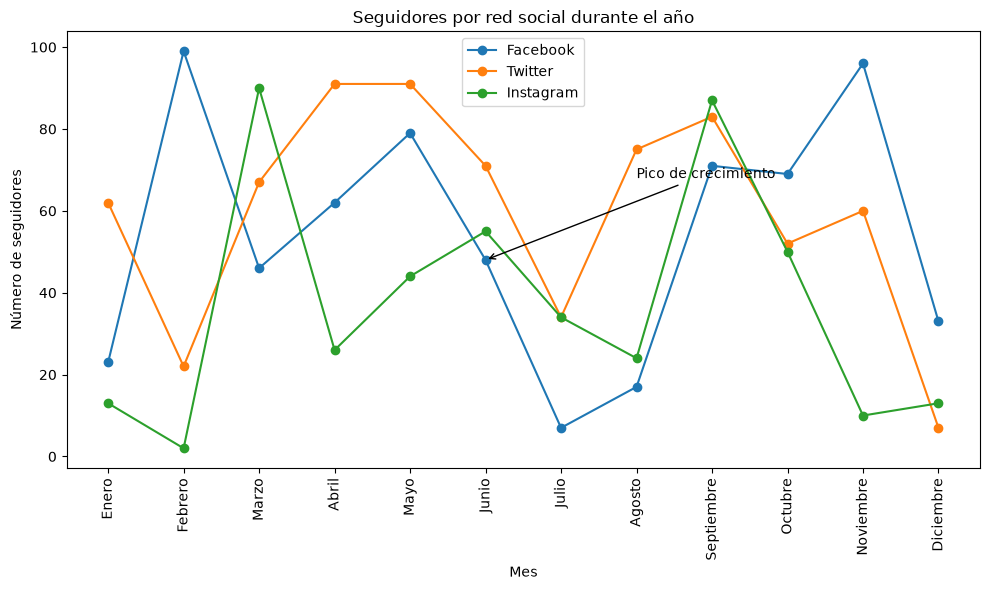

In [39]:
# Your solution HERE !!!!
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
         'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

y0 = np.random.randint(0, 100, size=12)
y1 = np.random.randint(0, 100, size=12)
y2 = np.random.randint(0, 100, size=12)

plt.figure(figsize=(10, 6))
plt.plot(meses, y0, label='Facebook', marker='o')
plt.plot(meses, y1, label='Twitter', marker='o')
plt.plot(meses, y2, label='Instagram', marker='o')

plt.title('Seguidores por red social durante el año')
plt.xlabel('Mes')
plt.ylabel('Número de seguidores')
plt.xticks(rotation=90)
plt.legend()

plt.annotate('Pico de crecimiento',
             xy=(meses[5], y0[5]),
             xytext=(meses[7], y0[5] + 20),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.tight_layout()
plt.show()
